In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
%cd /content/drive/MyDrive/AI-ML/Worksheet2/

/content/drive/MyDrive/AI-ML/Worksheet2


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split  # To split dataset
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [11]:
df = pd.read_csv("Iris.csv")

# Display first 5 rows of dataset
print("Dataset Preview:")
print(df.head())

# Show dataset structure (columns, data types, null values)
print("\nDataset Information:")
print(df.info())

Dataset Preview:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
mem

In [12]:
# Step 3: Extract features (X) and target labels (y)

X = df.iloc[:, 1:-1].values   # Select all rows, columns from index 1 to second last (features).
                              # First column is ignored because it is just an index.

y = df.iloc[:, -1].values     # Select the last column as the target variable (species/class).


# Step 4: Convert categorical labels to numeric
label_encoder = LabelEncoder()     # Create LabelEncoder object

y_encoded = label_encoder.fit_transform(y)
# Convert text labels (e.g., Setosa, Versicolor, Virginica) into integers (0,1,2)


# Step 5: One-Hot Encode the Labels
one_hot_encoder = OneHotEncoder(sparse_output=False)
# Create OneHotEncoder object. sparse_output=False returns a normal array instead of sparse matrix.

y_one_hot = one_hot_encoder.fit_transform(y_encoded.reshape(-1, 1))
# Convert integer labels into one-hot vectors.
# reshape(-1,1) converts the 1D array into a 2D column for the encoder.


# Display results
print("\nUnique Classes:", np.unique(y))      # Show unique class names

print("Encoded Labels:", np.unique(y_encoded))   # Show encoded numeric labels

print("One-Hot Encoded Labels:\n", y_one_hot[:5])
# Show first 5 rows of one-hot encoded labels


Unique Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Encoded Labels: [0 1 2]
One-Hot Encoded Labels:
 [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [13]:
#Srep6: Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_one_hot, test_size=0.2, random_state=42, stratify=y_one_hot)
#Output shapes
print("\nShapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)


Shapes:
X_train: (120, 4) y_train: (120, 3)
X_test: (30, 4) y_test: (30, 3)


In [14]:
import numpy as np
def softmax(z):
  z_shifted = z - np.max(z, axis = 1, keepdims = True)
  exp_z = np.exp(z_shifted)
  return exp_z /np.sum(exp_z, axis = 1, keepdims = True)

In [15]:
def loss_softmax(y_pred, y):
  epsilon = 1e-12
  y_pred = np.clip(y_pred, epsilon, 1.0-epsilon)
  n = y.shape[0]
  loss = -np.sum(y * np.log(y_pred)) /n
  return loss

In [16]:
def cost_softmax(X, y, W, b):
  n = X.shape[0]
  z = np.dot(X, W) + b
  y_pred = softmax(z)
  cost = loss_softmax(y_pred, y)
  return cost

In [17]:
def compute_gradient_softmax(X,y,W,b):
  n, d = X.shape
  z = np.dot(X,W) + b
  y_pred = softmax(z)
  grad_W = np.dot(X.T, (y_pred - y)) / n
  grad_b = np.sum(y_pred - y, axis = 0) / n
  return grad_W, grad_b

In [18]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimize weights and biases.

    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d)
    y (numpy.ndarray): One-hot encoded labels of shape (n, c)
    W (numpy.ndarray): Weight matrix of shape (d, c)
    b (numpy.ndarray): Bias vector of shape (c,)
    alpha (float): Learning rate
    n_iter (int): Number of iterations
    show_cost (bool): Display cost during training

    Returns:
    tuple: Optimized weights, biases, and cost history
    """

    cost_history = []

    for i in range(n_iter):

        # Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Update weights and bias
        W -= alpha * grad_W
        b -= alpha * grad_b

        # Compute cost
        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        # Print cost every 100 iterations
        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i}: Cost = {cost:.6f}")

    return W, b, cost_history

In [19]:
def predict_softmax(X, W, b):
    """
    Predict class labels using the trained softmax model.

    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d)
    W (numpy.ndarray): Weight matrix of shape (d, c)
    b (numpy.ndarray): Bias vector of shape (c,)

    Returns:
    numpy.ndarray: Predicted class labels of shape (n,)
    """

    # Compute scores (logits)
    z = np.dot(X, W) + b

    # Convert scores to probabilities using softmax
    y_pred = softmax(z)

    # Select class with highest probability
    predicted_classes = np.argmax(y_pred, axis=1)

    return predicted_classes

Iteration 0: Cost = 1.029663
Iteration 100: Cost = 0.472196
Iteration 200: Cost = 0.265603
Iteration 300: Cost = 0.222680
Iteration 400: Cost = 0.195324
Iteration 500: Cost = 0.176186
Iteration 600: Cost = 0.162004
Iteration 700: Cost = 0.151045
Iteration 800: Cost = 0.142304
Iteration 900: Cost = 0.135158
Iteration 999: Cost = 0.129251


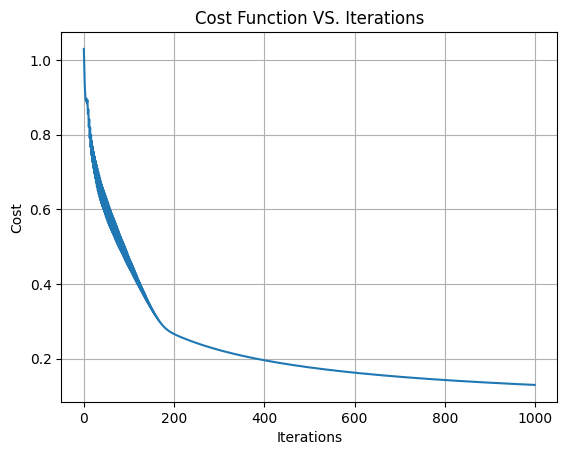

In [20]:
#Initialize the weights and biases
d = X_train.shape[1] #number of features
c = y_train.shape[1] #number of classes
W = np.random.randn(d, c) * 0.01 # small random weights
b = np.zeros(c)
#Set hyperparameters
alpha = 0.1 #Learning rate
n_iter = 1000 # no of iterations
#Train the model using gradient descent
W_opt, b_opt, cost_history = gradient_descent_softmax(X_train, y_train, W, b, alpha, n_iter, show_cost = True)
#Plot the cost history to visualize the convergence
plt.plot(cost_history)
plt.title("Cost Function VS. Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True)
plt.show()